In [2]:
import pandahouse
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
%matplotlib inline

In [3]:
connection = {
    'host' : 'http://clickhouse.lab.karpov.courses:8123',
    'password' : 'dpo_python_2020',
    'user' : 'student',
    'database' : 'simulator_20260320'
}

### ЗАДАНИЕ 1

#### Задача:<br>
При проведении А/А-теста было бы здорово убедиться в том, что наша система сплитования работает корректно, и ключевая метрика - CTR не отличается между группами. Если система сплитования работает корректно, то статистически значимые различия между двумя группами встречались бы только в результате случайного ложного срабатывания, при условии, что p_value < 0.05, то только приблизительно в 5% случаев у нас бы получались статистические значимые различия между 0 и 1 группой. Мы будем многократно извлекать подвыборки из наших данных, проводить t-test, а в конце посмотрим, в каком проценте случаев нам удалось отклонить нулевую гипотезу.

**Шаги:**
1) Берём данные АА-теста из следующего диапазона: с '2026-02-20' по '2026-02-26'<br>
2) Из групп 2 и 3 берём подвыборки без возвращения размером в 500 юзеров<br>
3) Сравниваем их t-тестом и сохраняем p-value (здесь и далее используем аргумент equal_var=False)<br>
4) Повторяем это 10000 раз<br>
5) Нарисуйте гистограмму получившихся p-value и посчитайте долю p-value, оказавшихся ниже порога значимости в 0.05.<br>
6) Что мы можем сказать по этому результату?<br>

In [4]:
#1) извлекаем данные
q = """
SELECT exp_group,
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM {db}.feed_actions
WHERE toDate(time) between '2026-02-20' and '2026-02-26'
    and exp_group in (2,3)
GROUP BY exp_group, user_id
"""
df = pandahouse.read_clickhouse(q, connection=connection)
df.groupby('exp_group').count()

,user_id,likes,views,ctr
exp_group,,,,
2,8362,8362,8362,8362
3,8425,8425,8425,8425


In [5]:
df

,exp_group,user_id,likes,views,ctr
0,3,115383,38,248,0.153226
1,3,10326,24,132,0.181818
2,3,123580,25,122,0.204918
3,2,131473,19,98,0.193878
4,2,23985,12,44,0.272727
...,...,...,...,...,...
16782,3,122008,20,123,0.162602
16783,2,25383,2,18,0.111111
16784,3,122190,15,56,0.267857
16785,2,108927,16,51,0.313725


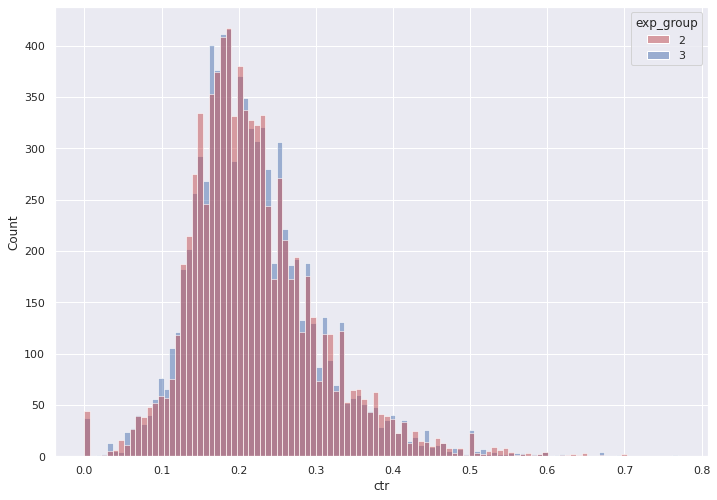

In [6]:
#визуализируем данные - гистограмма распределения CTR
sns.set(rc={'figure.figsize':(11.7,8.27)})
groups = sns.histplot(data = df,
              x='ctr',
              hue='exp_group',
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

**2. Из групп 2 и 3 берём подвыборки без возвращения размером в 500 юзеров**


In [7]:
sample_2= df[df.exp_group==2].ctr.sample(500, replace=False).tolist()
sample_3= df[df.exp_group==3].ctr.sample(500, replace=False).tolist()

**3. Сравниваем их t-тестом и сохраняем p-value (здесь и далее используем аргумент equal_var=False)** <br> **Повторяем это 10000 раз**

In [8]:
stats.ttest_ind(df[df.exp_group==2].ctr.sample(500, replace=False).tolist(), 
                df[df.exp_group==3].ctr.sample(500, replace=False).tolist(),
                equal_var=False)[1]

0.12056745185000782

In [17]:
# повторяем этот шаг 1000 раз, сохраняя получившиеся p-value в список.
p_values = [stats.ttest_ind(df[df.exp_group==2].ctr.sample(500, replace=False).tolist(), 
                            df[df.exp_group==3].ctr.sample(500, replace=False).tolist(),
                            equal_var=False)[1] for _ in range(10000)]
#убедимся, что длина списка = 10000
len(p_values) 

10000

**4. Нарисуйте гистограмму получившихся p-value и посчитайте долю p-value, оказавшихся ниже порога значимости в 0.05.** 

<Axes: ylabel='Count'>

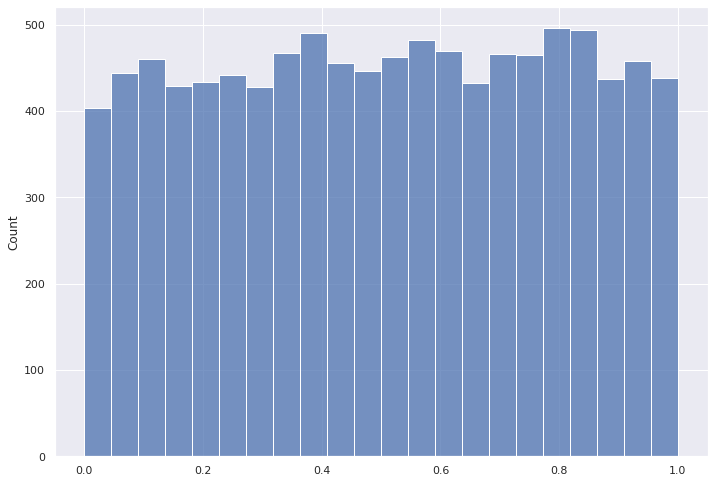

In [18]:
#гистограмма получившихся p-value
sns.histplot(p_values)

In [20]:
#Подсчитаем долю p-values, оказавшихся ниже порога значимости. Статистической разницы между группами нет, но в 0.0449 случаях мы ошибёмся
cnt = len([x for x in p_values if x < 0.05])
cnt/len(p_values) 

0.0449

**Вывод:**
Распределение получившихся p-value является примерно 
равномерным
. Доля p-value ниже порога значимости составляет около 
0.047
. Это 
примерно столько, сколько
 мы ожидаем. Значит, система сплитования 
работает корректно
.